# DrugEx ROCS Quick Start: Shape-Based RL

RL training for CCR2 ligand design using RDKit ROCS shape similarity scoring.

**Prerequisites:** Run fine-tuning first (`python prepare_models.py`)

**What This Does:**
- Trains RL model to generate CCR2 ligands optimized for shape similarity (ROCS) and synthetic accessibility
- Uses predefined settings from `config.py`
- Saves trained model for molecule generation

## ROCS Threshold Validation

Before RL training, we validate the ROCS threshold used to reward shape-similar molecules. 

**Why:** The threshold determines which molecules are considered "desired" during RL. Too high → miss actives. Too low → reward decoys.

**Method:** ROC analysis compares 75 CCR2 actives vs 500 decoys using the same conformer settings as RL training. We find the optimal threshold that maximizes separation (Youden's Index).

Results validate whether `config.py`'s `ROCS_THRESHOLD = 1.2` is appropriate or should be adjusted.

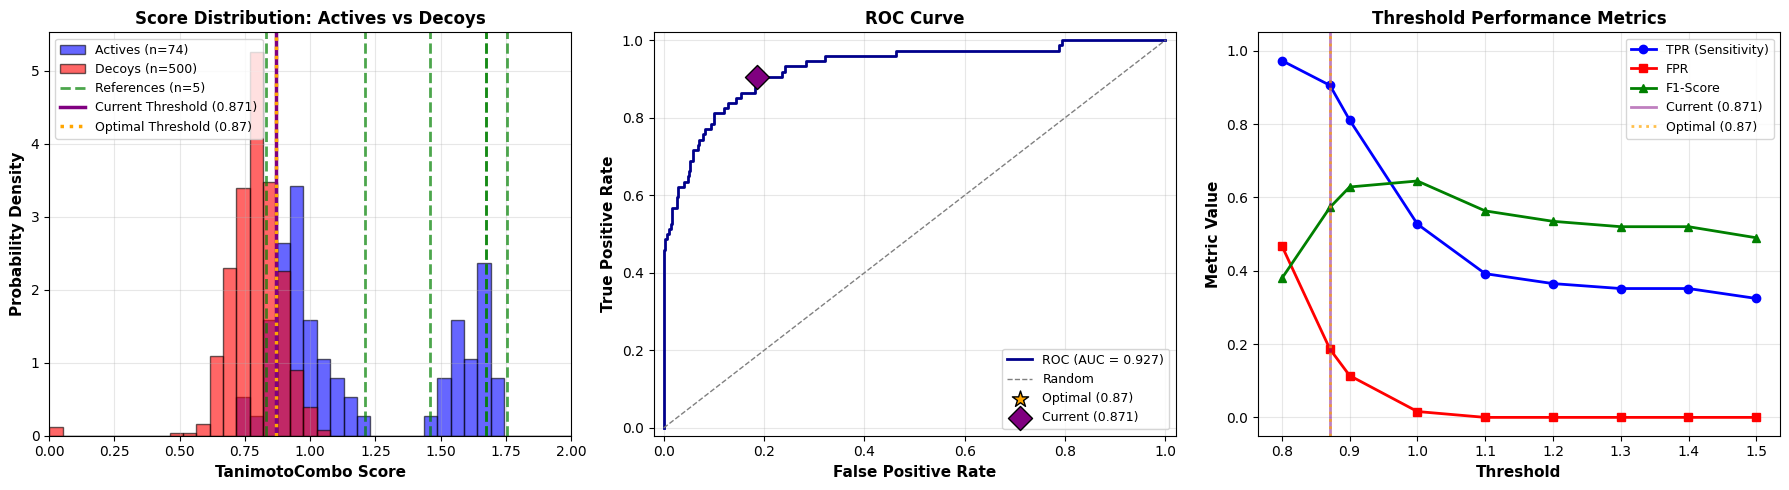

Current config threshold: 0.871
Optimal threshold (Youden's Index): 0.871


In [6]:
# Run threshold validation (uses config.py defaults automatically)
from threshold_analysis import run_threshold_analysis
from config import ROCS_THRESHOLD

results = run_threshold_analysis(
    actives_csv='rocs_rl_ccr/rdkit_cdpkit/actives_decoys/actives_ccr2_N75.csv',
    decoys_csv='rocs_rl_ccr/rdkit_cdpkit/actives_decoys/decoys_ccr2_N500.csv',
    verbose=False,  # Minimal output
    show_plots=True
)

# Display threshold recommendation
optimal_threshold = results['optimal_threshold']
print(f"Current config threshold: {ROCS_THRESHOLD}")
print(f"Optimal threshold (Youden's Index): {optimal_threshold:.3f}")


In [1]:
# Imports
import time
import pandas as pd
import matplotlib.pyplot as plt
from drugex.training.explorers import SequenceExplorer
from drugex.training.monitors import FileMonitor
from config import setup_rl_rdkit, RL_EPOCHS, RL_EPSILON, RL_N_SAMPLES

In [2]:
# Setup (loads models, creates environment with predefined settings)
agent, mutate, env, output_dir = setup_rl_rdkit()

Vocabulary loaded: 95 tokens
Environment created with RDKit ROCS + SA scorers
Agent loaded from pretrained model
Mutate network loaded from fine-tuned model

Setup complete! Using device: cuda:0


In [3]:
# Create RL explorer
explorer = SequenceExplorer(
    agent=agent,
    env=env,
    mutate=mutate,
    epsilon=RL_EPSILON,
    n_samples=RL_N_SAMPLES,
)

print(f"RL Config: {RL_EPOCHS} epochs, epsilon={RL_EPSILON}, samples={RL_N_SAMPLES}")

RL Config: 50 epochs, epsilon=0.2, samples=1000


In [9]:
# Train RL model
output_base = output_dir / 'CCR2_rdkit_reinforced'
monitor = FileMonitor(str(output_base), save_smiles=True, reset_directory=False)


In [ ]:

start = time.time()
explorer.fit(monitor=monitor, epochs=RL_EPOCHS)
monitor.close()

print(f"\nCompleted in {(time.time()-start)/60:.1f} minutes")
print(f"Model saved: {output_base}.pkg")

In [11]:
df = pd.read_csv(f'{output_base}_fit.tsv', sep='\t')
df.head(5)


,Epoch,valid_ratio,unique_ratio,desired_ratio,avg_amean,avg_gmean,loss_train,best_epoch
0,1,0.96,0.96,0.32,0.864,0.859,0.089,1
1,2,0.95,0.95,0.24,0.857,0.850,0.155,1
2,3,0.95,0.95,0.29,0.888,0.884,0.096,1
3,4,0.97,0.97,0.35,0.881,0.873,0.109,4
4,5,0.97,0.97,0.37,0.890,0.884,0.100,5


In [ ]:
df.tail(5)

,Epoch,valid_ratio,unique_ratio,desired_ratio,avg_amean,avg_gmean,loss_train,best_epoch
45,46,0.98,0.98,0.58,0.945,0.937,0.072,36
46,47,0.96,0.95,0.70,0.971,0.962,0.069,36
47,48,0.97,0.96,0.66,0.989,0.980,0.070,36
48,49,1.00,0.99,0.61,0.971,0.962,0.072,36
49,50,0.99,0.98,0.67,0.974,0.967,0.050,36


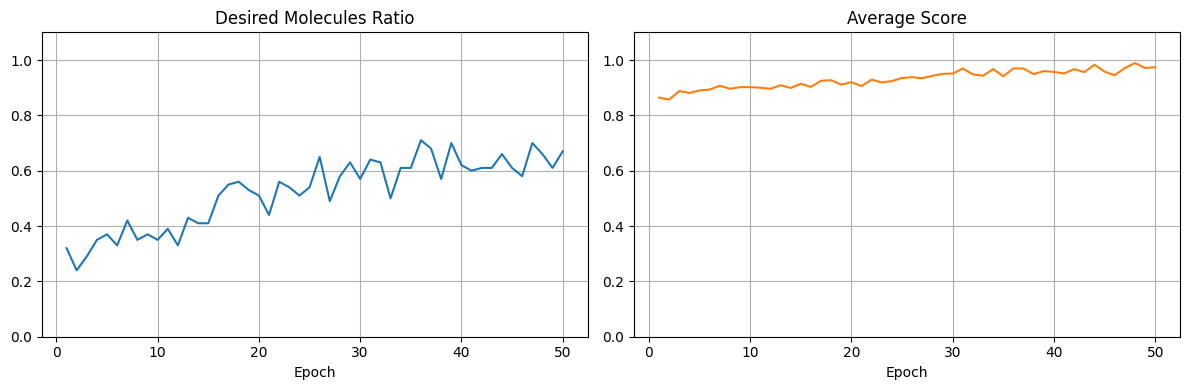

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(f'{output_base}_fit.tsv', sep='\t')

df.plot(x='Epoch', y=['desired_ratio', 'avg_amean'], subplots=True, layout=(1,2),
        figsize=(12,4), ylim=(0,1.1), grid=True, legend=False, title=['Desired Molecules Ratio','Average Score'])

plt.tight_layout()
plt.show()


### Training summary
- **Desired Molecules Ratio (left)**: Rises from ~0.25 to ~0.6–0.7 over 50 epochs with oscillations, indicating more molecules meet the criteria as training progresses.
- **Average Score (right)**: Starts high (~0.87) and gradually improves to ~0.97–0.99, staying stable with minor fluctuations—overall quality improves while the desired ratio increases.

## Next Steps

### Generate Molecules
```bash
python generate_molecules.py
```

### Try Other Backends
- CDPKit: `python run_cdpkit_rocs.py`
- OpenEye: `python run_openeye_rocs.py`

### Customize
Edit `config.py` to change:
- RL parameters (epochs, epsilon, samples)
- Conformer settings (max_conformers, max_isomers)
- Reference ligands (CCR2_SDF path)